In [5]:
from classes.simulator import ALMONDOSimulator
from classes.almondoModel import AlmondoModel
import networkx as nx
import ndlib.models.ModelConfig as mc
import json
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

## Funzioni

In [6]:
# For specific (λ, φ) points of interest, track individual runs
def analyze_single_runs(simulator: ALMONDOSimulator, lambda_val: float, phi_val: float, n_runs=20, overwrite: bool = False, drop_ev: bool = False):
    """Analyze individual run outcomes"""
    
    final_opinions = []
    trajectories = []
    
    print('Starting Monte Carlo runs')

    runs_data = []

    # Clear previous lobbyist strategies for new runs
    for id in range(simulator.n_lobbyists):
        simulator.lobbyists_data[id]['strategies'] = []

    for run in range(n_runs):
        print(f"Running simulation with lambda={lambda_val}, phi={phi_val}, nl={simulator.n_lobbyists}")
        print(f'Starting run {run+1}/{n_runs}')
        simulator.runpath = os.path.join(simulator.config_path, f'{run}')

        if not overwrite:
            if os.path.exists(f'{simulator.runpath}/status.json'):
                print(f'Run {run+1}/{n_runs} already performed, moving to next')
                continue
            else:
                os.makedirs(simulator.runpath, exist_ok=True)
        else:
            os.makedirs(simulator.runpath, exist_ok=True)
        
        if run<4: #in any case keeps first 4 runs for evolution plots
            system_status, final_distributions = simulator.single_run(lambda_val, phi_val,drop_ev=False)
        else:
            system_status, final_distributions = simulator.single_run(lambda_val, phi_val, drop_ev=drop_ev)
        
        runs_data.append(final_distributions)
        
        # Store final average opinion
        final_status = final_distributions['final_probabilities'] # list(system_status['status'].values())
        final_opinions.append(np.mean(final_status))
        
        # Store trajectory for plotting
        trajectory = [np.mean(list(it['status'].values())) for it in system_status]
        trajectories.append(trajectory)

        
        print('Saving configuration to file')
        simulator.save_config()

        print('Saving final distributions to file')
        filename = os.path.join(simulator.config_path, 'runs_data.json')
        with open(filename, 'w') as f:
            json.dump(runs_data, f)

    
    return final_opinions, trajectories

## Parametri

In [2]:
NLs = [0, 1, 2, 3, 4, 20] #number of lobbyists in the simulations
params = {
    'N': 500,
    'p_o': 0.01,
    'p_p': 0.99,
    'initial_distribution': 'uniform',
    'T': 10000, # max number of iterations
    # 'lambda_values': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    # 'phi_values': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'base': 'results_tests'
}    

In [7]:
nl = 2 # number of lobbyists
t = 2000 # number of iterations where lobbyists are active 
int_rate = 0.2 # interaction rate of the lobbyists per time-step
nruns = 100

# Test at key (lambda, phi) points
lam_points = [0.55]
phi_points = [
    0.0,   # In the lobbyist influence region
    0.06,  # In the V-shape (around the minimum of anomaly)
    0.1,   # High probability isolated point
    0.12,  # Near the edge of the lobbyist influence region
    0.15,  # Near the edge of the lobbyist influence region
    0.2,   # Just outside the lobbyist influence
    0.3    # In the peer effect region
]
params['lambda_values'] = lam_points
params['phi_values'] = phi_points

params['scenario'] = f'sensitivity_analysis_strategy_length/{nl}_lobbyists/{t}_steps/'
params['n_lobbyists'] = nl
b = int(int_rate*params['N']*t) # budget of lobbyists in the simulation 
if nl > 0:
    params['lobbyists_data'] = dict()
    for id in range(nl):
        # strategy type can be 'random', 'frontloading' or 'backloading'
                    params['lobbyists_data'][id] = {'m': id%2, 'B': b, 'c': 1, 'strategies': [], 'T': t, 'strategy_type': 'random'}

os.makedirs(params['base'], exist_ok=True)
path = os.path.join(params['base'], params['scenario'])
os.makedirs(path, exist_ok=True)

with open(os.path.join(path, 'initial_config.json'), 'w') as f:
    json.dump(params, f, indent=4)

print(f'performing simulations for {params["scenario"]}')

simulator = ALMONDOSimulator(**params, nruns=nruns)
# simulator.execute_experiments(overwrite_runs=False,drop_evolution=True)

performing simulations for sensitivity_analysis_strategy_length/2_lobbyists/2000_steps/
explored lambda values are [0.55]
explored phi values are [0.0, 0.06, 0.1, 0.12, 0.15, 0.2, 0.3]
Creating strategies
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Saving strategy to file
Sav

Starting experiments
Starting configuration lambda=0.55, phi=0.0
Starting Monte Carlo runs
Running simulation with lambda=0.55, phi=0.0, nl=2
Starting run 1/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  7.22it/s]


Configuration ended


 30%|███       | 3025/10000 [00:02<00:04, 1506.51it/s]


Convergence reached after 3025 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.0, nl=2
Starting run 2/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


...

Convergence reached after 3016 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.0, nl=2
Starting run 100/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  6.64it/s]


Configuration ended


 30%|███       | 3018/10000 [00:01<00:04, 1564.74it/s]


Convergence reached after 3018 iterations
Saving configuration to file
Saving final distributions to file

(λ=0.55, φ=0.0):
  Average: 0.459
  Std: 0.487
  Min: 0.010
  Max: 0.990
  Distribution: [54  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 46]


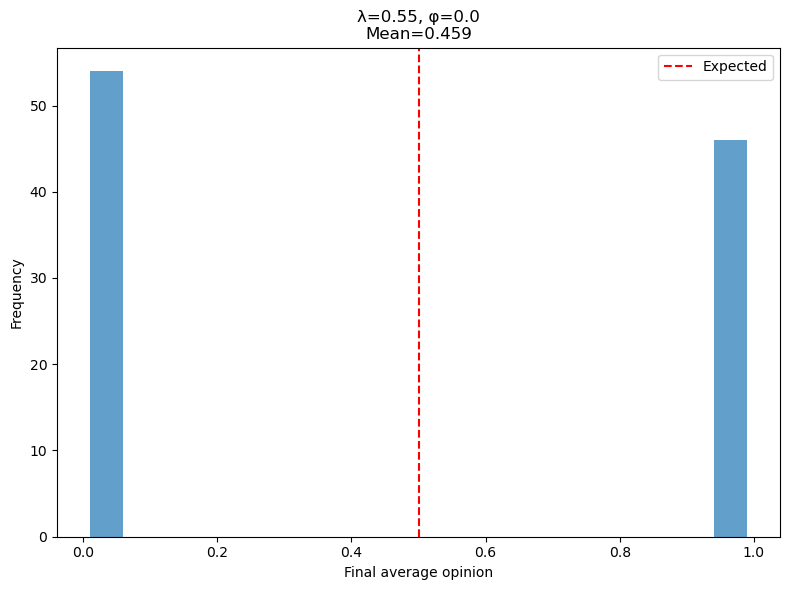

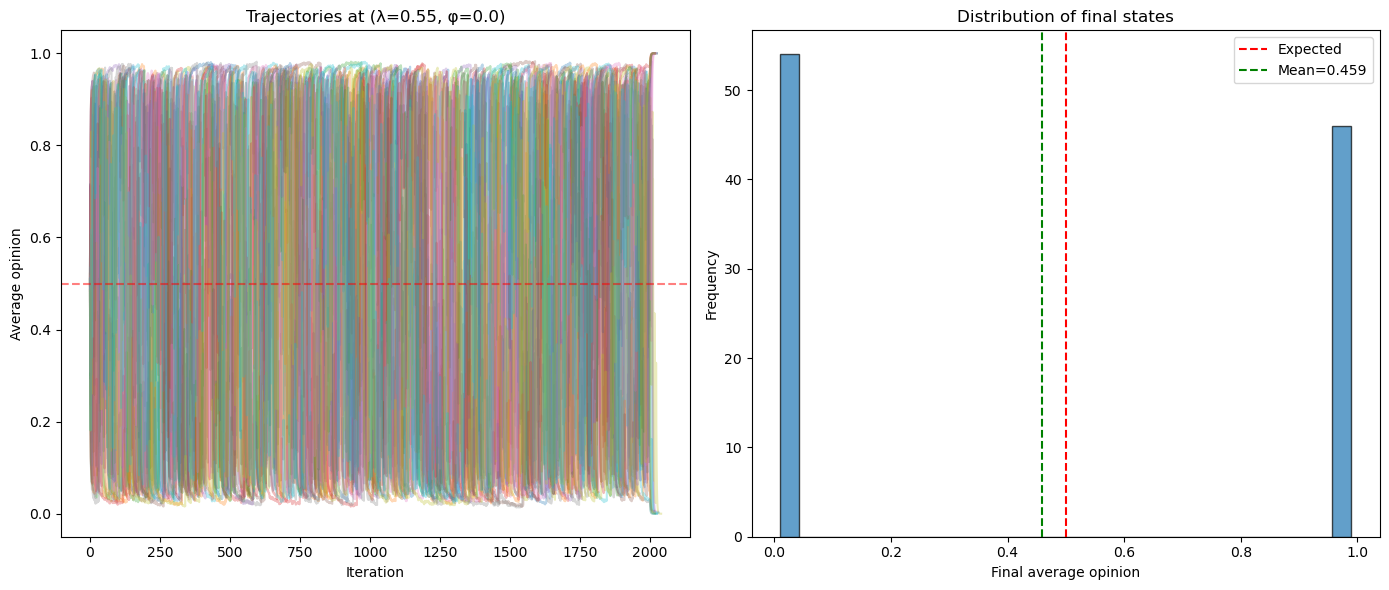

Starting configuration lambda=0.55, phi=0.06
Starting Monte Carlo runs
Running simulation with lambda=0.55, phi=0.06, nl=2
Starting run 1/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  9.35it/s]


Configuration ended


 30%|███       | 3019/10000 [00:01<00:04, 1510.33it/s]


Convergence reached after 3019 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.06, nl=2
Starting run 2/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


...

Convergence reached after 3013 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.06, nl=2
Starting run 100/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  9.00it/s]


Configuration ended


 30%|███       | 3014/10000 [00:01<00:04, 1647.07it/s]


Convergence reached after 3014 iterations
Saving configuration to file
Saving final distributions to file

(λ=0.55, φ=0.06):
  Average: 0.126
  Std: 0.315
  Min: 0.010
  Max: 0.990
  Distribution: [88  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 12]


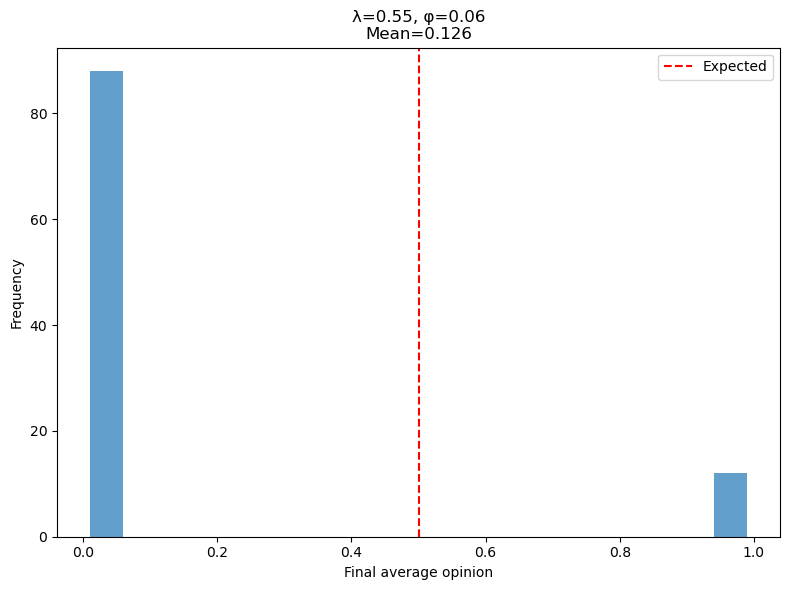

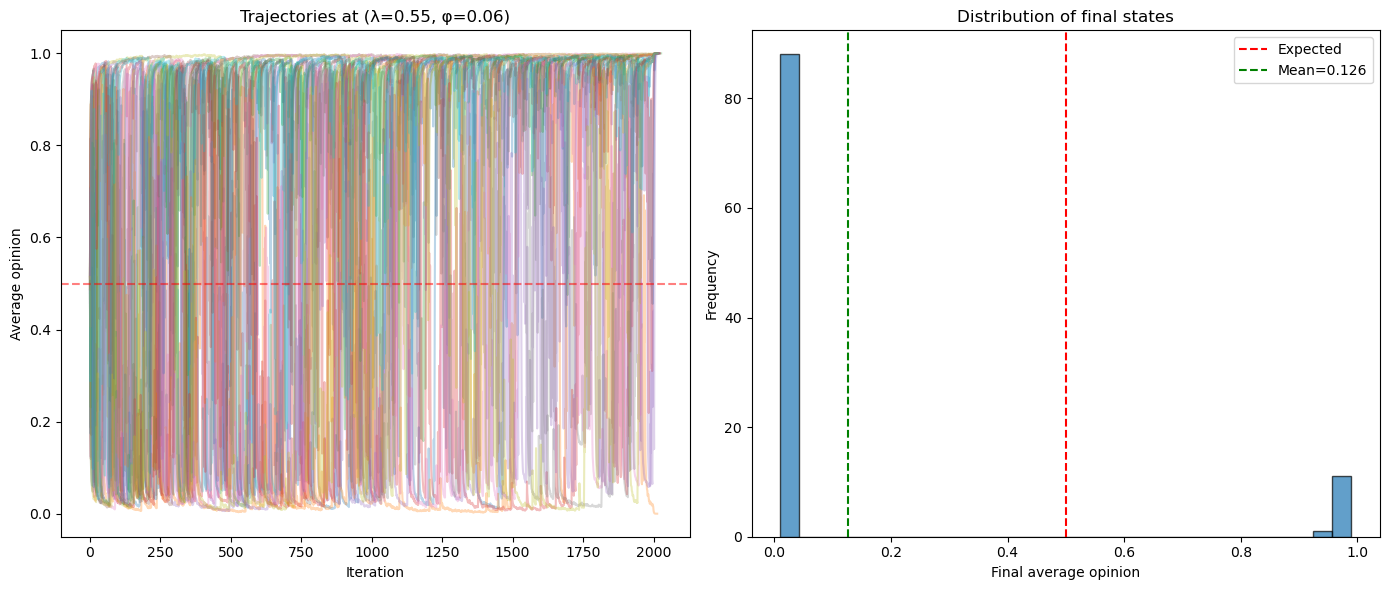

Starting configuration lambda=0.55, phi=0.1
Starting Monte Carlo runs
Running simulation with lambda=0.55, phi=0.1, nl=2
Starting run 1/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  8.71it/s]


Configuration ended


 30%|███       | 3018/10000 [00:01<00:04, 1608.97it/s]


Convergence reached after 3018 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.1, nl=2
Starting run 2/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


...

Convergence reached after 3011 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.1, nl=2
Starting run 100/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  6.01it/s]


Configuration ended


 30%|███       | 3014/10000 [00:02<00:05, 1217.24it/s]


Convergence reached after 3014 iterations
Saving configuration to file
Saving final distributions to file

(λ=0.55, φ=0.1):
  Average: 0.637
  Std: 0.470
  Min: 0.010
  Max: 0.990
  Distribution: [36  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 64]


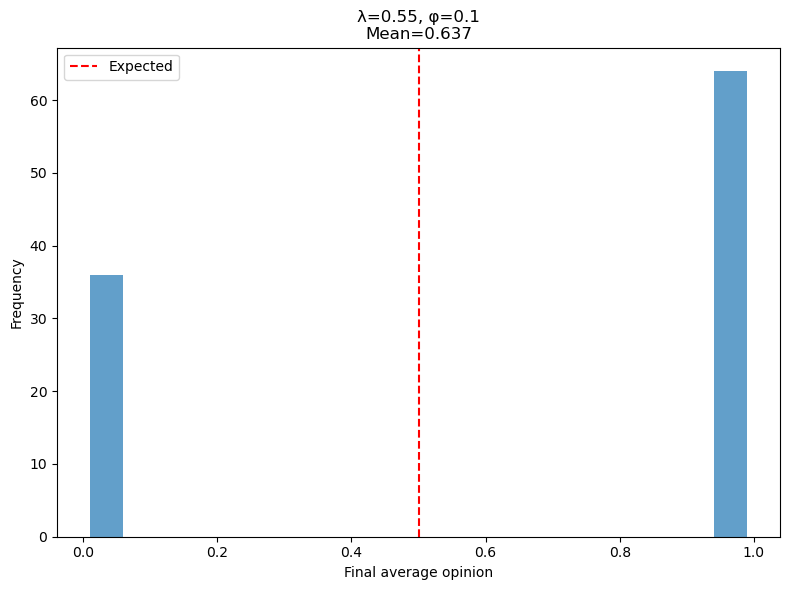

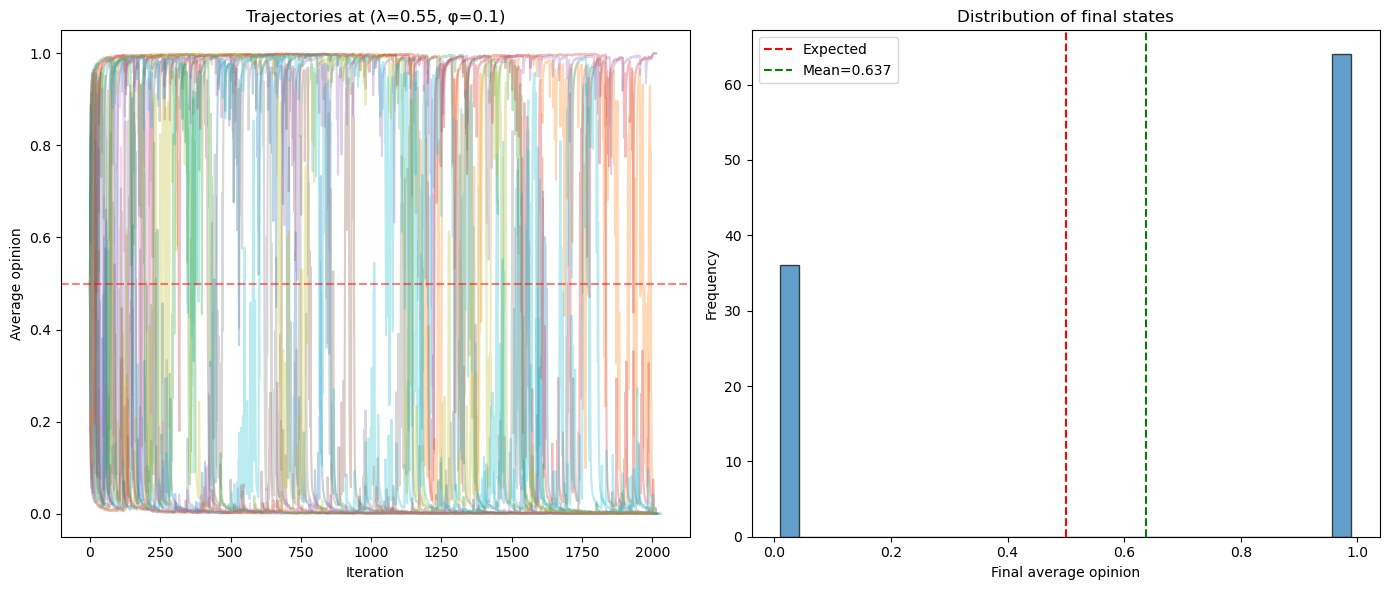

Starting configuration lambda=0.55, phi=0.12
Starting Monte Carlo runs
Running simulation with lambda=0.55, phi=0.12, nl=2
Starting run 1/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  7.55it/s]


Configuration ended


 24%|██▍       | 2435/10000 [00:02<00:06, 1177.30it/s]


Convergence reached after 2435 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.12, nl=2
Starting run 2/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


...

Convergence reached after 2933 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.12, nl=2
Starting run 100/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  8.20it/s]


Configuration ended


 28%|██▊       | 2787/10000 [00:02<00:06, 1083.26it/s]


Convergence reached after 2787 iterations
Saving configuration to file
Saving final distributions to file

(λ=0.55, φ=0.12):
  Average: 0.510
  Std: 0.490
  Min: 0.010
  Max: 0.990
  Distribution: [49  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 51]


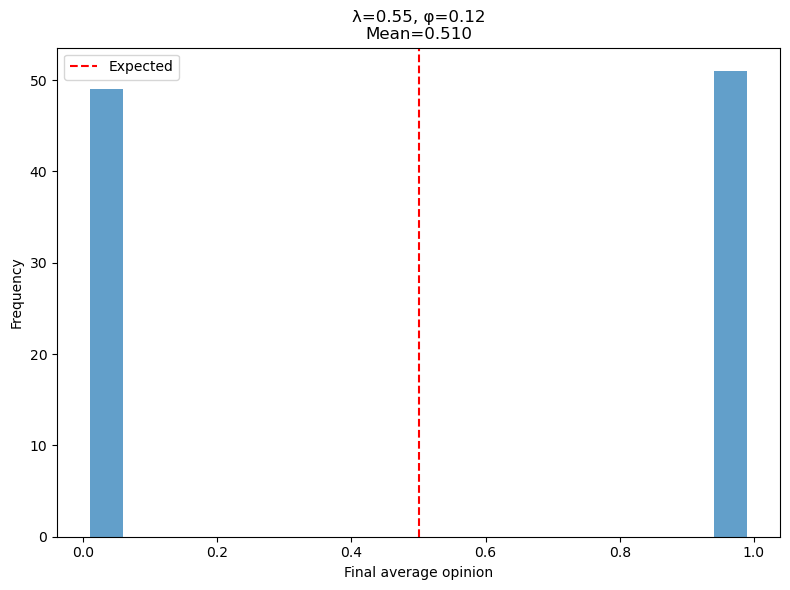

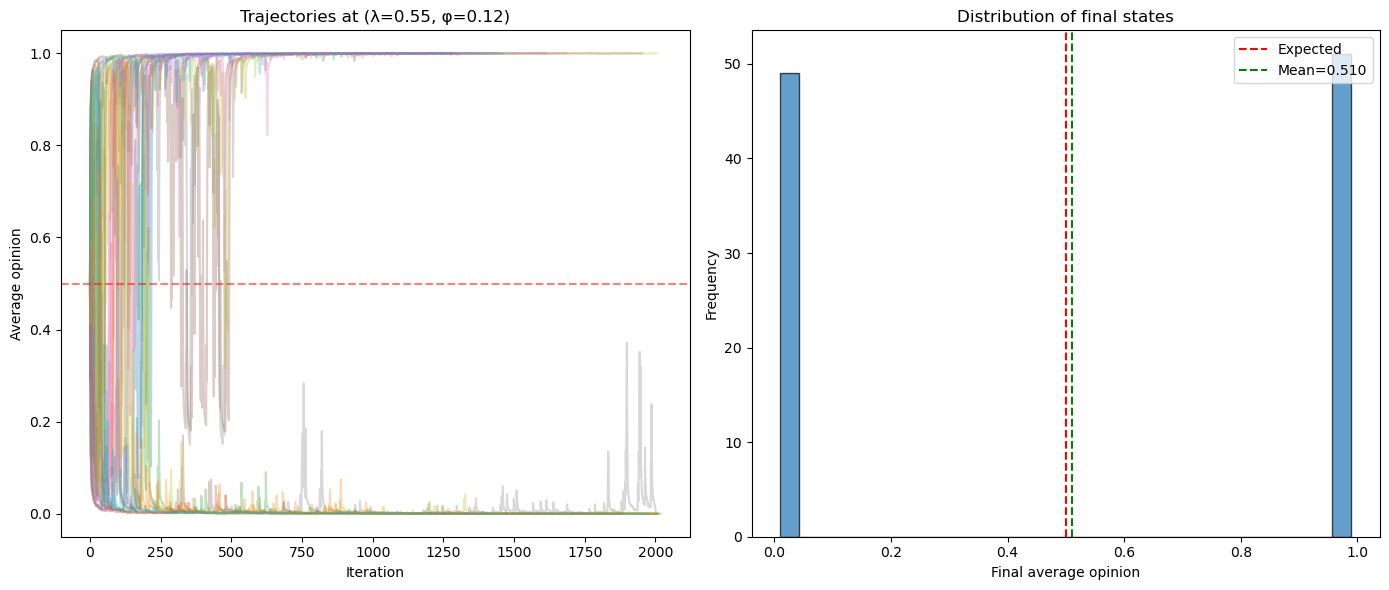

Starting configuration lambda=0.55, phi=0.15
Starting Monte Carlo runs
Running simulation with lambda=0.55, phi=0.15, nl=2
Starting run 1/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  7.29it/s]


Configuration ended


 25%|██▌       | 2538/10000 [00:02<00:07, 947.29it/s] 


Convergence reached after 2538 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.15, nl=2
Starting run 2/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


...

Convergence reached after 1851 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.15, nl=2
Starting run 100/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  9.66it/s]


Configuration ended


 17%|█▋        | 1684/10000 [00:01<00:06, 1326.17it/s]


Convergence reached after 1684 iterations
Saving configuration to file
Saving final distributions to file

(λ=0.55, φ=0.15):
  Average: 0.422
  Std: 0.484
  Min: 0.010
  Max: 0.990
  Distribution: [58  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 42]


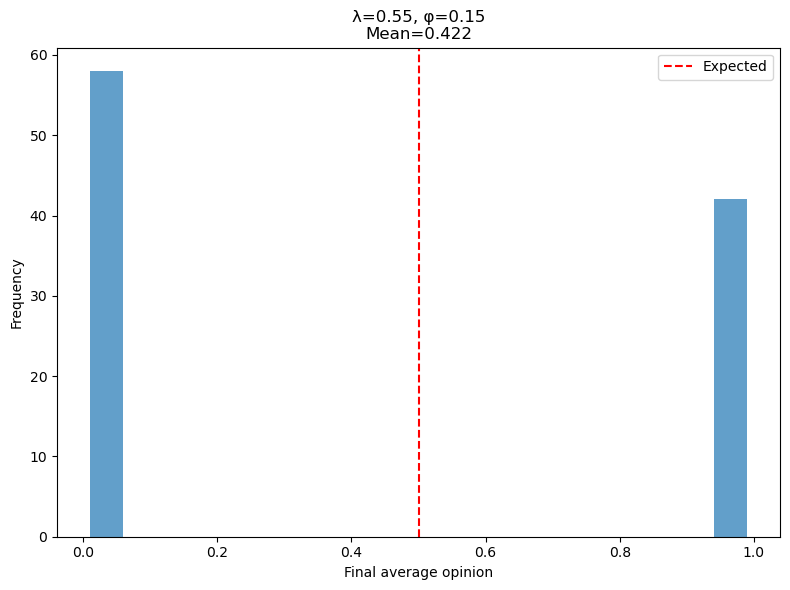

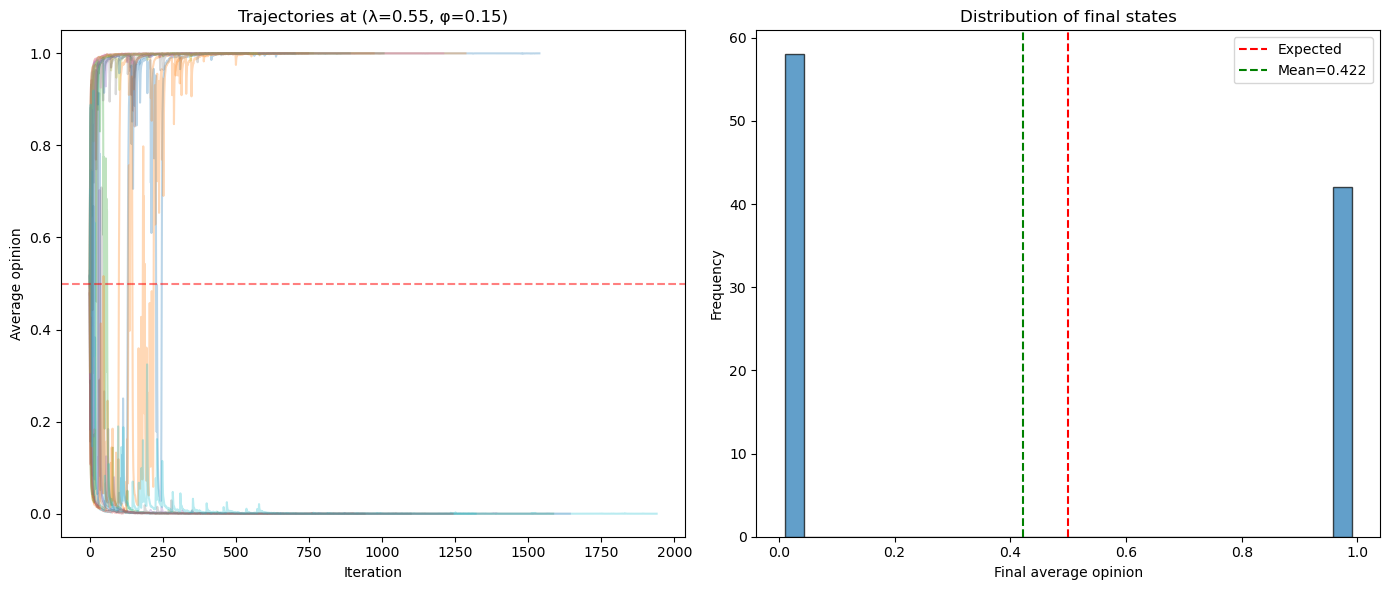

Starting configuration lambda=0.55, phi=0.2
Starting Monte Carlo runs
Running simulation with lambda=0.55, phi=0.2, nl=2
Starting run 1/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00, 10.39it/s]


Configuration ended


 15%|█▍        | 1451/10000 [00:01<00:06, 1248.22it/s]


Convergence reached after 1451 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.2, nl=2
Starting run 2/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


...

Convergence reached after 1399 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.2, nl=2
Starting run 100/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  8.21it/s]


Configuration ended


 15%|█▍        | 1455/10000 [00:01<00:09, 887.85it/s]


Convergence reached after 1455 iterations
Saving configuration to file
Saving final distributions to file

(λ=0.55, φ=0.2):
  Average: 0.520
  Std: 0.490
  Min: 0.010
  Max: 0.990
  Distribution: [48  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 52]


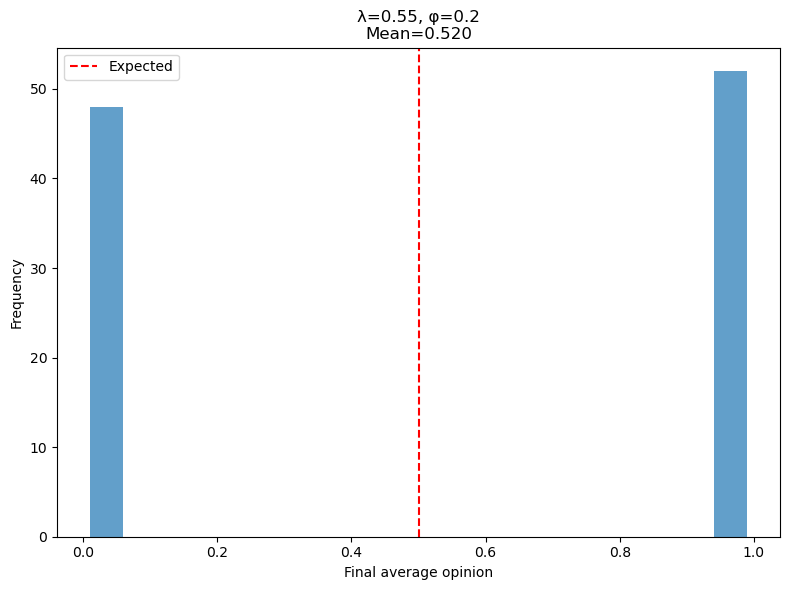

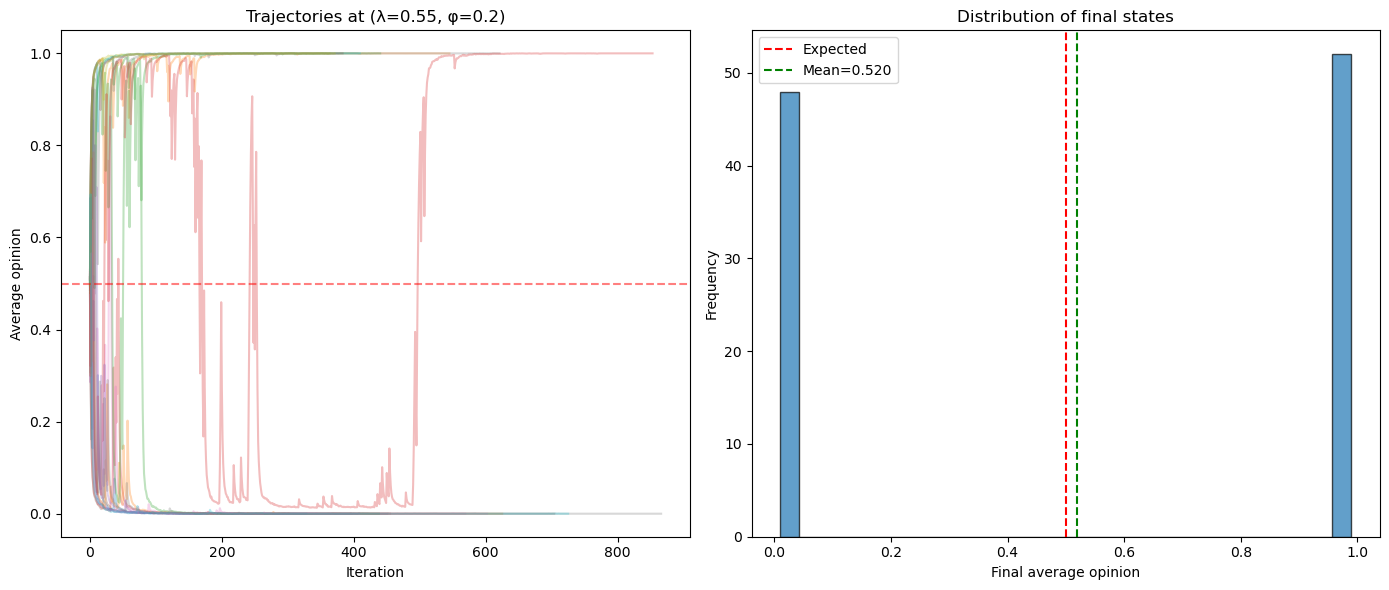

Starting configuration lambda=0.55, phi=0.3
Starting Monte Carlo runs
Running simulation with lambda=0.55, phi=0.3, nl=2
Starting run 1/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  6.91it/s]


Configuration ended


 12%|█▏        | 1187/10000 [00:01<00:09, 909.38it/s]


Convergence reached after 1187 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.3, nl=2
Starting run 2/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


...

Convergence reached after 1152 iterations
Saving configuration to file
Saving final distributions to file
Running simulation with lambda=0.55, phi=0.3, nl=2
Starting run 100/100
Creating configuration object
Assigning p_o and p_p parameters
p_o=0.01, p_p=0.99
Assigning homogeneous lambda
Assigning homogeneous phi
Configuring model: assigning graph, parameters, and initial distribution of weights
Assign strategies to lobbyists if any


100%|██████████| 2/2 [00:00<00:00,  8.82it/s]


Configuration ended


 12%|█▏        | 1176/10000 [00:01<00:08, 1033.38it/s]


Convergence reached after 1176 iterations
Saving configuration to file
Saving final distributions to file

(λ=0.55, φ=0.3):
  Average: 0.431
  Std: 0.485
  Min: 0.010
  Max: 0.990
  Distribution: [57  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 43]


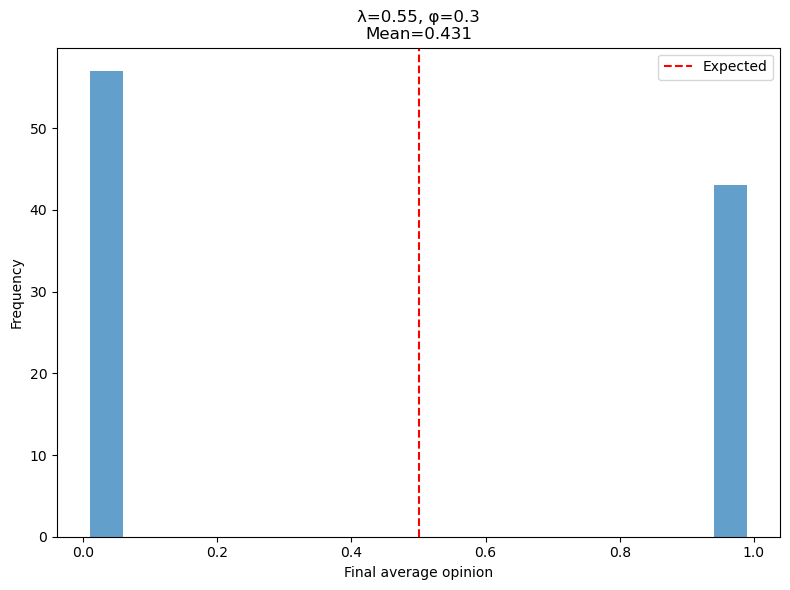

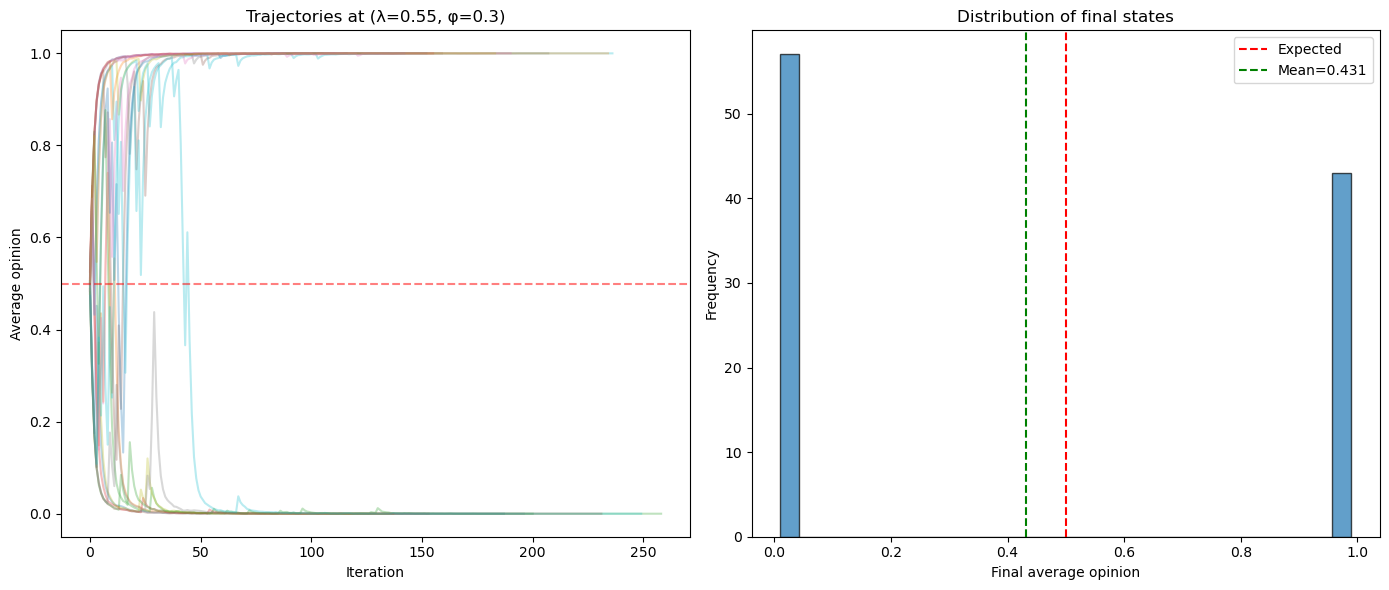

In [8]:
print('Starting experiments')

for _, (lam, phi) in enumerate([(l, p) for l in simulator.lambdas for p in simulator.phis]):

    print(f'Starting configuration lambda={lam}, phi={phi}')

    simulator.config_path = os.path.join(simulator.scenario_path, f'{lam}_{phi}')
    os.makedirs(simulator.config_path, exist_ok=True)

    finals, trajs = analyze_single_runs(simulator, lam, phi, n_runs=nruns)

    print(f"\n(λ={lam}, φ={phi}):")
    print(f"  Average: {np.mean(finals):.3f}")
    print(f"  Std: {np.std(finals):.3f}")
    print(f"  Min: {np.min(finals):.3f}")
    print(f"  Max: {np.max(finals):.3f}")
    
    # Check for bimodality / polarization
    # Check if individual runs show (polarization) bimodal distribution 
    histogram, bins = np.histogram(finals, bins=20)
    print(f"  Distribution: {histogram}")
    
    plt.figure(figsize=(8, 6))
    plt.hist(finals, bins=20, alpha=0.7)
    plt.axvline(0.5, color='red', linestyle='--', label='Expected')
    plt.title(f'λ={lam}, φ={phi}\nMean={np.mean(finals):.3f}')
    plt.xlabel('Final average opinion')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

# Visualized spaghetti plot

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    for traj in trajs[:20]:  # Plot first 20 trajectories
        plt.plot(traj, alpha=0.3)
    plt.xlabel('Iteration')
    plt.ylabel('Average opinion')
    plt.title(f'Trajectories at (λ={lam}, φ={phi})')
    plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.hist(finals, bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel('Final average opinion')
    plt.ylabel('Frequency')
    plt.title('Distribution of final states')
    plt.axvline(0.5, color='red', linestyle='--', label='Expected')
    plt.axvline(np.mean(finals), color='green', linestyle='--', label=f'Mean={np.mean(finals):.3f}')
    plt.legend()

    plt.tight_layout()
    plt.show()
    plt.close()